# Homework 1 — Spectral Clustering on the Iris Dataset

**Discipline:** Numerical Programming in Python

**Program:** M.S. in AI/ML Engineering — Neoversity

We have to group the 150 Iris observations into three clusters **without using the labels**, and then check how well the discovered structure matches the real species with a confusion matrix.

In [1]:
# Environment setup & imports
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.optimize import linear_sum_assignment
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    adjusted_rand_score,
    confusion_matrix,
    normalized_mutual_info_score,
)

sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42

## Step 1: Load the Data and Build a DataFrame

`load_iris(as_frame=True)` returns the four morphological measurements (in cm) together with the species codes. The codes are kept separately as `y_true` — they are the ground truth used **only for evaluation**, never for fitting.

In [2]:
iris = load_iris(as_frame=True)

y_true = iris.target.to_numpy()
class_names = list(iris.target_names)

df = iris.data.copy()
df.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
features = df.columns.tolist()
df["species"] = iris.target_names[y_true]

print(f"Observations: {df.shape[0]}, features: {len(features)}")
print(f"Missing values: {int(df.isna().sum().sum())}")
df.head()

Observations: 150, features: 4
Missing values: 0


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Step 2: Basic Statistical Characteristics

`describe()` gives the location and spread of every feature. The `range` column is added to make the difference in scale explicit — this is exactly what motivates standardization in Step 4.

In [3]:
summary = df[features].describe().T
summary["range"] = summary["max"] - summary["min"]
summary.round(2)

,count,mean,std,min,25%,50%,75%,max,range
sepal_length,150.0,5.84,0.83,4.3,5.1,5.80,6.4,7.9,3.6
sepal_width,150.0,3.06,0.44,2.0,2.8,3.00,3.3,4.4,2.4
petal_length,150.0,3.76,1.77,1.0,1.6,4.35,5.1,6.9,5.9
petal_width,150.0,1.20,0.76,0.1,0.3,1.30,1.8,2.5,2.4


## Step 3: Distribution of Observations by Class

Two views: the class balance itself, and a pair plot that shows how separable the classes are in the raw feature space.

species
setosa        50
versicolor    50
virginica     50


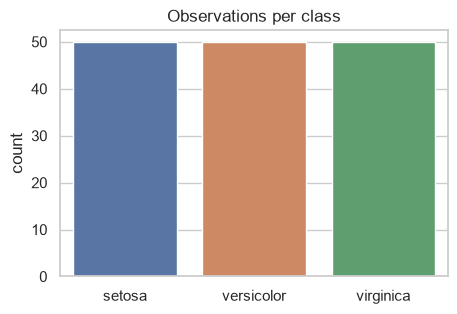

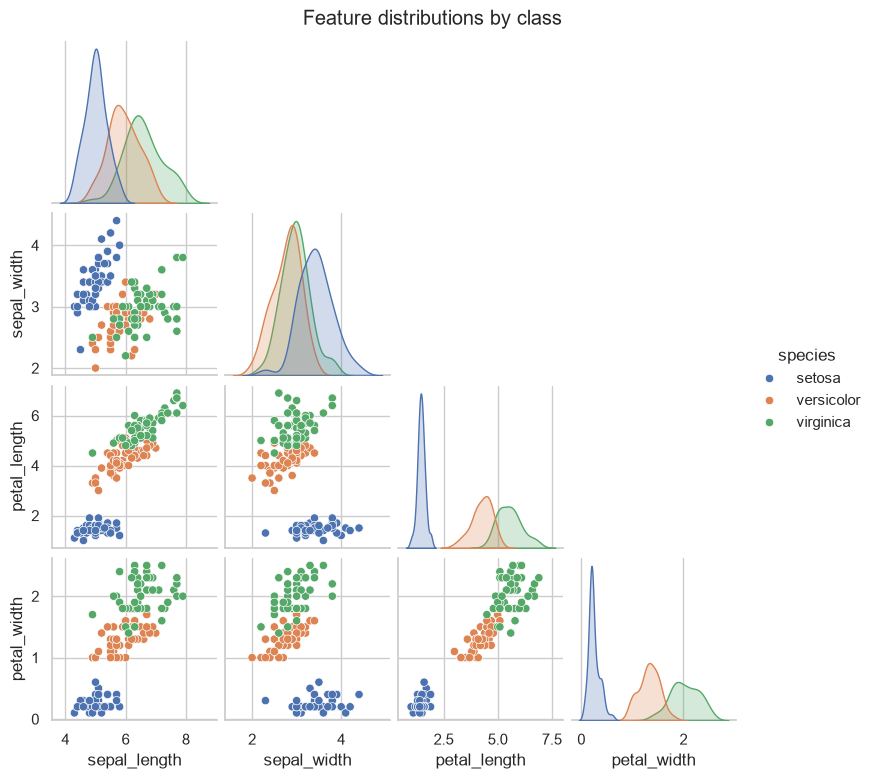

In [4]:
print(df["species"].value_counts().to_string())

fig, ax = plt.subplots(figsize=(5, 3.2))
sns.countplot(data=df, x="species", hue="species", legend=False, ax=ax)
ax.set(title="Observations per class", xlabel="", ylabel="count")
plt.show()

sns.pairplot(df, vars=features, hue="species", diag_kind="kde", corner=True, height=1.9)
plt.suptitle("Feature distributions by class", y=1.02)
plt.show()

## Step 4: Standardization

Spectral clustering builds a similarity graph from pairwise distances, so features with a wider range would dominate the affinity matrix. `StandardScaler` centers every feature at 0 and scales it to unit variance:

$$z = \frac{x - \mu}{\sigma}$$

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

check = pd.DataFrame(
    {
        "mean_before": df[features].mean(),
        "std_before": df[features].std(ddof=0),
        "mean_after": X_scaled.mean(axis=0),
        "std_after": X_scaled.std(axis=0),
    },
    index=features,
)
check.round(3)

,mean_before,std_before,mean_after,std_after
sepal_length,5.843,0.825,-0.0,1.0
sepal_width,3.057,0.434,-0.0,1.0
petal_length,3.758,1.759,-0.0,1.0
petal_width,1.199,0.760,-0.0,1.0


## Step 5: Spectral Clustering

Spectral clustering embeds the similarity graph into the space of its leading Laplacian eigenvectors and runs k-means there, which lets it separate clusters that are not linearly separable. The result depends strongly on how the graph is built, so two affinity options are compared:

- `nearest_neighbors` — a sparse k-NN graph, controlled by `n_neighbors`;
- `rbf` — a dense Gaussian kernel $\exp(-\gamma \lVert x_i - x_j \rVert^2)$, controlled by `gamma`.

Each configuration is scored against the true species with the Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI).

In [6]:
grid = [{"affinity": "nearest_neighbors", "n_neighbors": k} for k in (5, 10, 15, 20, 30)]
grid += [{"affinity": "rbf", "gamma": g} for g in (0.05, 0.1, 0.5, 1.0, 5.0)]

rows = []
for params in grid:
    # sklearn warns when the similarity graph falls apart -> keep it as a column instead of noise
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        labels = SpectralClustering(
            n_clusters=3, assign_labels="kmeans", random_state=RANDOM_STATE, **params
        ).fit_predict(X_scaled)

    key, value = next((k, v) for k, v in params.items() if k != "affinity")
    rows.append(
        {
            "affinity": params["affinity"],
            "parameter": f"{key}={value}",
            "ARI": adjusted_rand_score(y_true, labels),
            "NMI": normalized_mutual_info_score(y_true, labels),
            "connected_graph": not any(
                "not fully connected" in str(w.message) for w in caught
            ),
        }
    )

experiments = pd.DataFrame(rows).sort_values("ARI", ascending=False).reset_index(drop=True)
experiments.round(3)

,affinity,parameter,ARI,NMI,connected_graph
0,nearest_neighbors,n_neighbors=10,0.646,0.684,True
1,rbf,gamma=1.0,0.645,0.690,True
2,nearest_neighbors,n_neighbors=20,0.630,0.666,True
3,nearest_neighbors,n_neighbors=30,0.621,0.643,True
4,nearest_neighbors,n_neighbors=15,0.602,0.650,True
5,rbf,gamma=0.5,0.600,0.629,True
6,rbf,gamma=0.1,0.581,0.619,True
7,rbf,gamma=0.05,0.580,0.617,True
8,rbf,gamma=5.0,0.564,0.717,True
9,nearest_neighbors,n_neighbors=5,0.470,0.661,False


The k-NN graph with `n_neighbors=10` scores best, with `rbf` at `gamma=1.0` practically tied. The `connected_graph` column explains the worst result: at `n_neighbors=5` the neighborhood is so small that the similarity graph falls into disconnected components, the eigenvectors stop describing the dataset as a whole, and the score drops sharply (ARI 0.47). Large values go the other way — the graph becomes almost fully connected and the clustering degrades towards plain k-means.

The best configuration is refitted below as the final model.

In [7]:
model = SpectralClustering(
    n_clusters=3,
    affinity="nearest_neighbors",
    n_neighbors=10,
    assign_labels="kmeans",
    random_state=RANDOM_STATE,
)
clusters = model.fit_predict(X_scaled)
df["cluster"] = clusters

print("Cluster sizes:")
print(pd.Series(clusters).value_counts().sort_index().to_string())

Cluster sizes:
0    35
1    49
2    66


## Step 6: Predicted Clusters vs. Actual Classes

Cluster ids are arbitrary — cluster `0` has no reason to correspond to class `0`. Before the confusion matrix can be read along its diagonal, each cluster is matched to the class it overlaps most, solved as an optimal assignment problem with the Hungarian algorithm (`linear_sum_assignment` on the negated overlap counts).

ARI and NMI are computed from the raw cluster ids, since both metrics are invariant to relabeling.

In [8]:
overlap = confusion_matrix(y_true, clusters)
class_idx, cluster_idx = linear_sum_assignment(-overlap)
cluster_to_class = dict(zip(cluster_idx, class_idx))

y_pred = np.array([cluster_to_class[c] for c in clusters])

cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=[f"true {name}" for name in class_names],
    columns=[f"pred {name}" for name in class_names],
)

print(cm_df.to_string(), "\n")
print(f"Accuracy after alignment: {accuracy_score(y_true, y_pred):.4f}")
print(f"Adjusted Rand Index:      {adjusted_rand_score(y_true, clusters):.4f}")
print(f"Normalized Mutual Info:   {normalized_mutual_info_score(y_true, clusters):.4f}")

                 pred setosa  pred versicolor  pred virginica
true setosa               49                1               0
true versicolor            0               47               3
true virginica             0               18              32 

Accuracy after alignment: 0.8533
Adjusted Rand Index:      0.6465
Normalized Mutual Info:   0.6838


## Step 7: Visualize the Clustering Results

The confusion matrix as a heatmap, and the clustering projected onto the first two principal components — the true species on the left, the aligned clusters on the right with every mismatch circled.

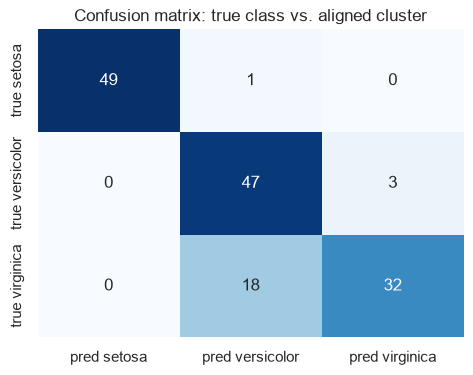

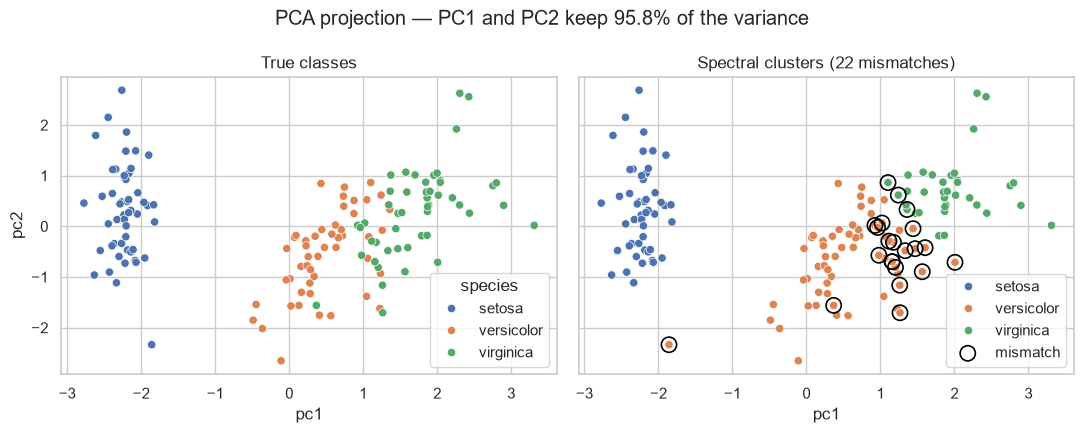

In [9]:
fig, ax = plt.subplots(figsize=(5.5, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("Confusion matrix: true class vs. aligned cluster")
plt.show()

pca = PCA(n_components=2, random_state=RANDOM_STATE)
components = pca.fit_transform(X_scaled)

plot_df = df.assign(
    pc1=components[:, 0],
    pc2=components[:, 1],
    predicted=iris.target_names[y_pred],
    correct=y_pred == y_true,
)
mismatched = plot_df[~plot_df["correct"]]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharex=True, sharey=True)
sns.scatterplot(data=plot_df, x="pc1", y="pc2", hue="species", ax=axes[0])
axes[0].set_title("True classes")

sns.scatterplot(data=plot_df, x="pc1", y="pc2", hue="predicted", ax=axes[1])
axes[1].scatter(
    mismatched["pc1"], mismatched["pc2"],
    s=120, facecolors="none", edgecolors="black", linewidths=1.2, label="mismatch",
)
axes[1].set_title(f"Spectral clusters ({len(mismatched)} mismatches)")
axes[1].legend()

fig.suptitle(f"PCA projection — PC1 and PC2 keep {pca.explained_variance_ratio_.sum():.1%} of the variance")
plt.tight_layout()
plt.show()

## Conclusion

Spectral clustering on the standardized Iris data recovers **128 of 150** observations correctly (85.3% accuracy after cluster-to-class alignment), with ARI = 0.646 and NMI = 0.684 — far above the ARI of about 0 that a random assignment would give, but clearly short of a perfect partition.

The confusion matrix shows where the error lives. *Setosa* is essentially solved (49/50): it is linearly separable from the rest by petal size alone, as the pair plot already suggested. The whole error concentrates on the *versicolor* / *virginica* boundary — 18 *virginica* observations fall into the *versicolor* cluster, against only 3 in the other direction. These two species overlap in feature space, so no unsupervised method can split them cleanly without additional information — in the PCA projection nearly every circled mismatch sits in the contact zone between the two point clouds.

Parameter choice mattered more than the choice of algorithm. Across the grid, ARI ranged from 0.47 to 0.65 for the same data and the same number of clusters: too small a neighborhood (`n_neighbors=5`) disconnected the similarity graph, while an overly sharp kernel (`gamma=5.0`) fragmented it. The sparse k-NN graph with `n_neighbors=10` proved the most stable choice.

Two practical takeaways: standardization is not optional here, since the affinity matrix is built from raw distances and petal length would otherwise dominate; and cluster labels must be aligned before a confusion matrix means anything — the raw matrix for this same model is almost empty on its diagonal, while the aligned one reads 49 / 47 / 32.